# FB Prohpet
<img src="https://i.postimg.cc/XvByNGLR/Screenshot-2025-11-04-192512.png"><br>
 Here g(t) is the trend function which models non-periodic changes in the value of the
 time series, s(t) represents periodic changes (e.g., weekly and yearly seasonality), and
 h(t) represents the efects of holidays which occur on potentially irregular schedules over
 one or more days. The error term et represents any idiosyncratic changes which are not
 accommodated by the model; later we will make the parametric assumption that t is
 normally distributed.

 ## 1. The Trend Model
  there are two trend models - a saturating growth model, and a piecewise linear model.<br>

  ### 1.1 Nonlinear, Saturating Growth
  This growth is typically modeled
 using the **logistic growth model**, which in its most basic form is<br>
  <img src="https://i.ibb.co/zzqpCz5/image.png"><br>
   with C the carrying capacity, k the growth rate, and m an o set parameter.
<br><br>There are two important aspects of growth at Facebook that are not captured in above equation.<br>
 First, the carrying capacity is not constant as the number of people in the world who
 have access to the Internet increases, so does the growth ceiling. We thus replace the xed
 capacity C with a time-varying capacity C(t).
 <br><br>Second, the growth rate is not constant.
 New products can profoundly alter the rate of growth in a region, so the model must be
 able to incorporate a varying rate in order to t historical data<br>
 <img src="https://i.ibb.co/hx7SB9MJ/image.png">
 <img src="https://i.ibb.co/pv7ynwKt/image.png" alt="image" border="0">

 ### 1.2 Piecewise linear model
 <img src="https://i.ibb.co/fY4x6Bgp/image.png" alt="image" border="0">

### 1.3 How prophet internally handles t
 <img src="https://i.ibb.co/LWRn229/image.png" alt="image" border="0">

### 1.4 automatic changepoint selection
<img src="https://i.ibb.co/hzGtvJ0/image.png" alt="image" border="0">

## 2 - Seasonality
<img src="https://i.ibb.co/L70zZN5/image.png" alt="image" border="0"><br>
<img src="https://i.ibb.co/4RSXQhKh/image.png" alt="image" border="0">
## Holiday
   For each holiday i, let Di be the set of past
 and future dates for that holiday. We add an indicator function representing whether time t is during holiday i, and assign each holiday a parameter ki which is the corresponding
 change in the forecast.
 <img src="https://i.ibb.co/bjQkj3tw/image.png" alt="image" border="0">

 ## Training
 <img src="https://i.ibb.co/jvcSNVz6/image.png" alt="image" border="0">

In [1]:
import pandas as pd
df=pd.read_csv("https://raw.githubusercontent.com/krishnaik06/FbProphet/refs/heads/master/airline_passengers.csv")

In [2]:
df.head()

,Month,Thousands of Passengers
0,1949-01,112.0
1,1949-02,118.0
2,1949-03,132.0
3,1949-04,129.0
4,1949-05,121.0


In [3]:
df.tail()

,Month,Thousands of Passengers
140,1960-09,508.0
141,1960-10,461.0
142,1960-11,390.0
143,1960-12,432.0
144,International airline passengers: monthly tota...,NaN


In [4]:
df.drop(144,axis=0,inplace=True)

<Axes: >

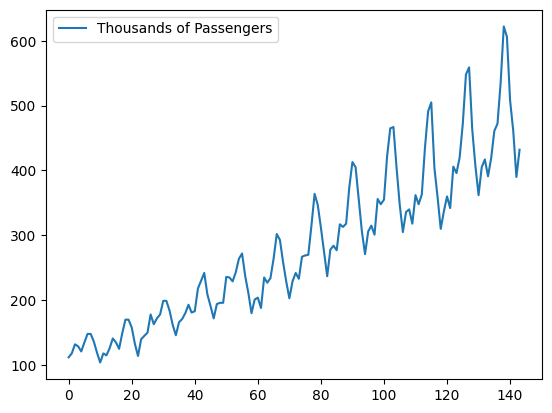

In [5]:
df.plot()

In [6]:
# rename column like this
df.rename({'Month':'ds','Thousands of Passengers':'y'},axis=1,inplace=True)

In [7]:
df['ds']=pd.to_datetime(df['ds'])

In [8]:
!pip install prophet --quiet


In [9]:
from prophet import Prophet

In [10]:
dir(Prophet)

['__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_load_stan_backend',
 '_logistic_uncertainty',
 '_make_historical_mat_time',
 '_make_trend_shift_matrix',
 '_sample_uncertainty',
 'add_country_holidays',
 'add_group_component',
 'add_regressor',
 'add_seasonality',
 'calculate_initial_params',
 'construct_holiday_dataframe',
 'fit',
 'flat_growth_init',
 'flat_trend',
 'fourier_series',
 'initialize_scales',
 'linear_growth_init',
 'logistic_growth_init',
 'make_all_seasonality_features',
 'make_future_dataframe',
 'make_holiday_features',
 'make_seasonality_features',
 'parse_seasonality_args',
 'percentile',
 'piecewise_linear',
 

In [11]:
!pip uninstall prophet -y --quiet
!pip install prophet cmdstanpy --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 48.2 MB/s eta 0:00:00


In [12]:
# if model is logistic then we have to provide a cap column in dataframe which is basically upper range of prediction -> see equation for more detail
model=Prophet(growth='linear',yearly_seasonality=True,weekly_seasonality=True,daily_seasonality=False)
model.fit(df)

In [13]:
model.component_modes

{'additive': ['yearly',
  'weekly',
  'additive_terms',
  'extra_regressors_additive',
  'holidays'],
 'multiplicative': ['multiplicative_terms', 'extra_regressors_multiplicative']}

In [15]:
future_dates=model.make_future_dataframe(periods=12,freq='MS')

In [16]:
model.predict(future_dates)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1949-01-01,106.537199,59.642099,116.925740,106.537199,106.537199,-20.238883,-20.238883,-20.238883,1.175173,1.175173,1.175173,-21.414056,-21.414056,-21.414056,0.0,0.0,0.0,86.298316
1,1949-02-01,108.703484,47.352435,104.877038,108.703484,108.703484,-33.416393,-33.416393,-33.416393,-3.809134,-3.809134,-3.809134,-29.607259,-29.607259,-29.607259,0.0,0.0,0.0,75.287091
2,1949-03-01,110.660129,76.324717,136.825143,110.660129,110.660129,-3.730567,-3.730567,-3.730567,-3.809134,-3.809134,-3.809134,0.078567,0.078567,0.078567,0.0,0.0,0.0,106.929561
3,1949-04-01,112.826414,82.802900,139.165081,112.826414,112.826414,-0.486229,-0.486229,-0.486229,4.750951,4.750951,4.750951,-5.237180,-5.237180,-5.237180,0.0,0.0,0.0,112.340185
4,1949-05-01,114.922819,79.555965,138.187354,114.922819,114.922819,-5.003232,-5.003232,-5.003232,-1.610246,-1.610246,-1.610246,-3.392986,-3.392986,-3.392986,0.0,0.0,0.0,109.919587
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,1961-08-01,509.003766,543.152165,601.846236,508.714512,509.269852,64.098087,64.098087,64.098087,-3.809134,-3.809134,-3.809134,67.907221,67.907221,67.907221,0.0,0.0,0.0,573.101852
152,1961-09-01,512.124809,507.536603,561.902333,511.768281,512.454206,21.603655,21.603655,21.603655,4.750951,4.750951,4.750951,16.852704,16.852704,16.852704,0.0,0.0,0.0,533.728464
153,1961-10-01,515.145173,461.406823,521.197114,514.708357,515.552873,-23.388545,-23.388545,-23.388545,-1.610246,-1.610246,-1.610246,-21.778300,-21.778300,-21.778300,0.0,0.0,0.0,491.756628
154,1961-11-01,518.266217,433.567408,492.007963,517.744187,518.728148,-57.013324,-57.013324,-57.013324,1.087630,1.087630,1.087630,-58.100953,-58.100953,-58.100953,0.0,0.0,0.0,461.252893


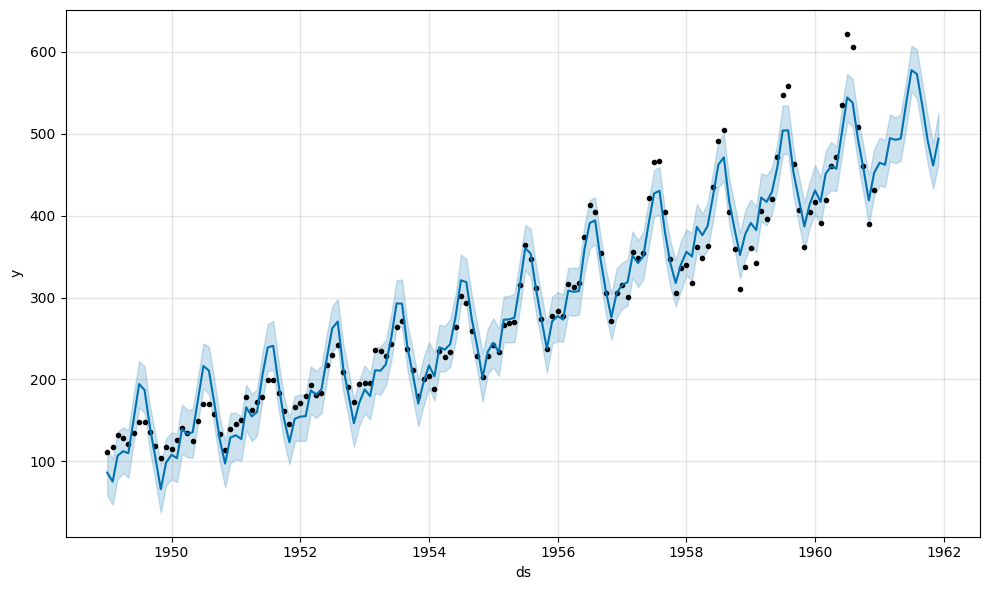

In [18]:
prediction=model.predict(future_dates)
fig=model.plot(prediction)
fig.show()

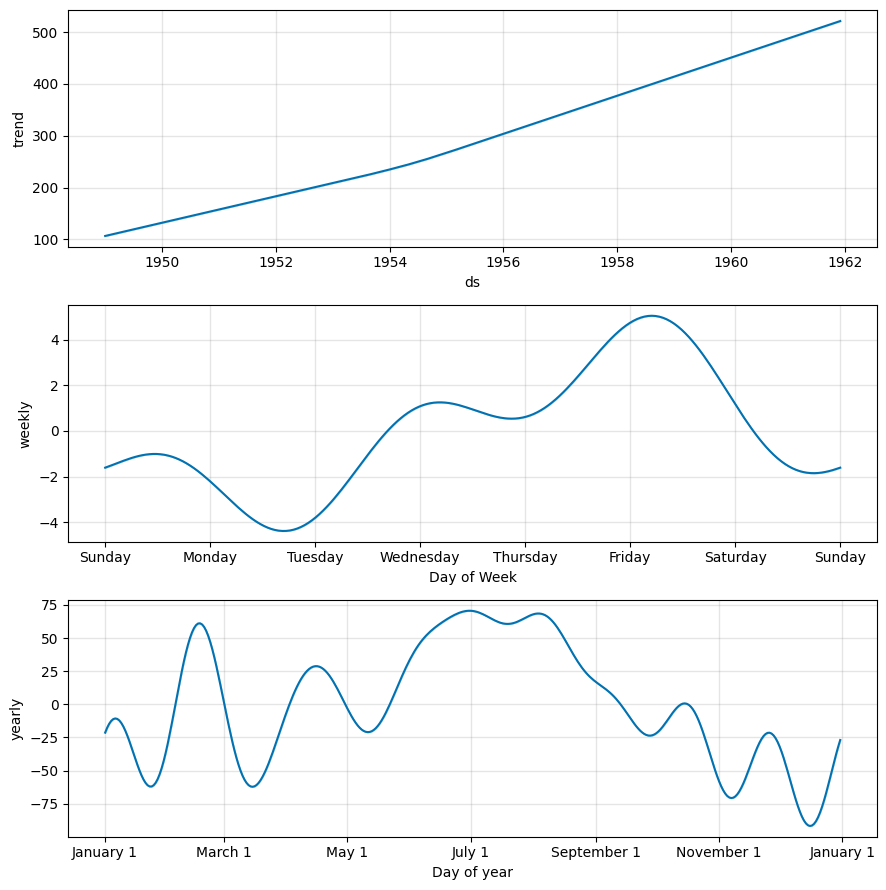

In [19]:
fig=model.plot_components(prediction)
fig.show()

<img src="https://i.ibb.co/Kx1Zzkwv/image.png" alt="image" border="0">

In [21]:
df.shape

(144, 2)

In [25]:
from prophet.diagnostics import cross_validation

# generally period is taken as half of horizon
df_cv=cross_validation(model,initial='730 days',period='180 days',horizon='365 days')

INFO:prophet:Making 19 forecasts with cutoffs between 1951-01-18 00:00:00 and 1959-12-02 00:00:00


  0%|          | 0/19 [00:00<?, ?it/s]

INFO:prophet:n_changepoints greater than number of observations. Using 19.
INFO:prophet:n_changepoints greater than number of observations. Using 23.


In [27]:
df_cv.head()

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,1951-02-01,126.161310,126.154108,126.167681,150.0,1951-01-18
1,1951-03-01,142.024216,142.002166,142.044990,178.0,1951-01-18
2,1951-04-01,133.415551,133.372211,133.456690,163.0,1951-01-18
3,1951-05-01,151.930345,151.863653,151.993951,172.0,1951-01-18
4,1951-06-01,196.218832,196.124252,196.308734,178.0,1951-01-18


In [26]:
from prophet.diagnostics import performance_metrics
df_p=performance_metrics(df_cv)
df_p

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,40 days,1255.944032,35.439301,27.849635,0.085258,0.089955,0.087619,0.227273
1,42 days,1235.728910,35.152936,28.655267,0.091572,0.093045,0.094569,0.181818
2,46 days,1210.789076,34.796395,29.473189,0.101010,0.094702,0.101912,0.136364
3,47 days,1327.294444,36.432052,30.933200,0.099233,0.094702,0.099859,0.136364
4,48 days,1321.365312,36.350589,30.748948,0.099110,0.094702,0.099795,0.136364
...,...,...,...,...,...,...,...,...
165,359 days,902.746527,30.045741,25.129607,0.084026,0.082979,0.082820,0.204545
166,360 days,902.278509,30.037951,25.174982,0.084005,0.082979,0.082789,0.181818
167,362 days,998.362719,31.596878,26.384601,0.082537,0.082979,0.081925,0.181818
168,364 days,960.957274,30.999311,25.109852,0.079056,0.082979,0.078581,0.227273


/usr/local/lib/python3.12/dist-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


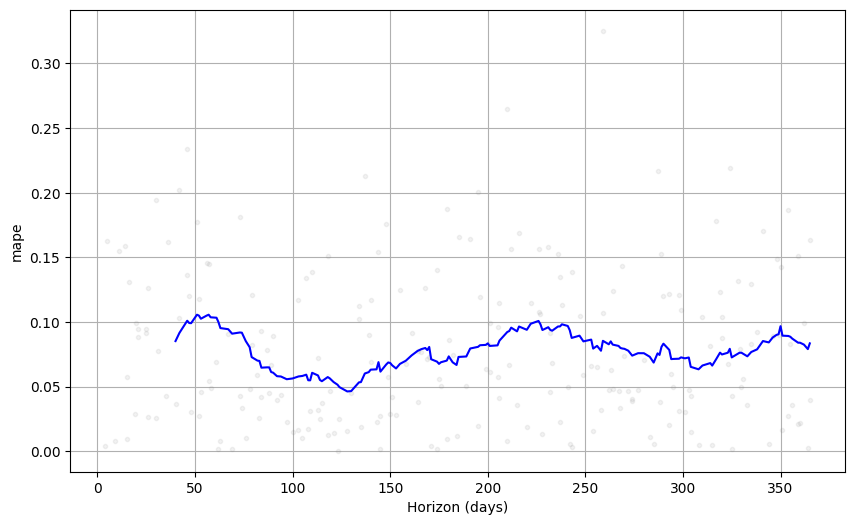

In [28]:
from prophet.plot import plot_cross_validation_metric
fig=plot_cross_validation_metric(df_cv,metric='mape')
fig.show()